<a href="https://colab.research.google.com/github/Willemann0511/MiniProjeto2/blob/main/MiniProjeto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import zipfile
from google.colab import drive

# ==========================================
# 1. MONTAR O GOOGLE DRIVE
# ==========================================
print("🔄 Conectando ao Google Drive...")
drive.mount('/content/drive')

# ==========================================
# 2. DEFINIR O CAMINHO DO ZIP NO DRIVE
# ==========================================
ZIP_DRIVE_PATH = '/content/drive/MyDrive/MiniProjeto2/casting_512x512.zip'

# Pasta de destino local no Colab (SSD ultra rápido)
LOCAL_EXTRACT_PATH = '/content/dataset'

# ==========================================
# 3. EXTRAÇÃO AUTOMÁTICA PARA O DISCO LOCAL
# ==========================================
if os.path.exists(ZIP_DRIVE_PATH):
    print(f"📦 Arquivo ZIP localizado em: {ZIP_DRIVE_PATH}")
    print("⏳ Extraindo arquivos para o disco local do Colab (aguarde alguns segundos)...")

    with zipfile.ZipFile(ZIP_DRIVE_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_PATH)

    print("✅ Extração concluída com sucesso!")

    # Define DATASET_PATH para o diretório extraído
    # Nota: Se o zip continha uma pasta interna (ex: 'casting_data'), ajustamos o caminho
    extracted_contents = os.listdir(LOCAL_EXTRACT_PATH)

    if len(extracted_contents) == 1 and os.path.isdir(os.path.join(LOCAL_EXTRACT_PATH, extracted_contents[0])):
        DATASET_PATH = os.path.join(LOCAL_EXTRACT_PATH, extracted_contents[0])
    else:
        DATASET_PATH = LOCAL_EXTRACT_PATH

    print(f"📁 DATASET_PATH configurado para: {DATASET_PATH}")
    print("Conteúdo da pasta do dataset:", os.listdir(DATASET_PATH))

else:
    print(f"⚠️ ATENÇÃO: O arquivo '{ZIP_DRIVE_PATH}' não foi encontrado.")
    print("Verifique se o nome do arquivo .zip e as pastas no seu Drive estão corretos.")

🔄 Conectando ao Google Drive...
Mounted at /content/drive
📦 Arquivo ZIP localizado em: /content/drive/MyDrive/MiniProjeto2/casting_512x512.zip
⏳ Extraindo arquivos para o disco local do Colab (aguarde alguns segundos)...
✅ Extração concluída com sucesso!
📁 DATASET_PATH configurado para: /content/dataset/casting_512x512
Conteúdo da pasta do dataset: ['ok_front', 'def_front']


📷 Carregando imagem de amostra: /content/dataset/casting_512x512/def_front/cast_def_0_5006.jpeg


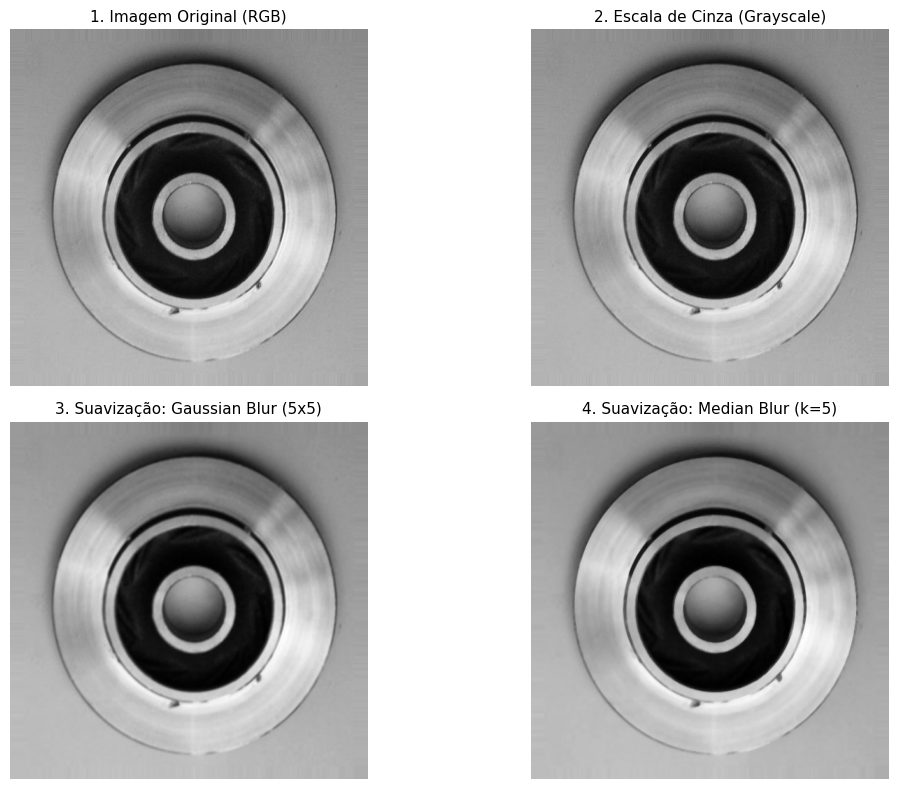

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Sprint 2 - Análise Exploratória Clássica (OpenCV)

# ==========================================
# 1. DEFINIÇÃO DIRETA DOS CAMINHO E LEITURA
# ==========================================
# Diretórios das classes (ajusta se a pasta do dataset tiver uma subpasta intermediária)
def_folder = os.path.join(DATASET_PATH, 'def_front')
ok_folder = os.path.join(DATASET_PATH, 'ok_front')

# Pega o primeiro arquivo de imagem da pasta 'def_front'
sample_filename = os.listdir(def_folder)[0]
sample_image_path = os.path.join(def_folder, sample_filename)

print(f"📷 Carregando imagem de amostra: {sample_image_path}")

# Leitura da imagem via OpenCV (Formato BGR)
img_bgr = cv2.imread(sample_image_path)

# Converter BGR para RGB para exibição no Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ==========================================
# 2. ESCALA DE CINZA (GRAYSCALE)
# ==========================================
# Descarta cores para focar na intensidade luminosa e reduzir processamento
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ==========================================
# 3. SUAVIZAÇÃO DE RUÍDO (GAUSSIAN & MEDIAN BLUR)
# ==========================================
# Gaussian Blur (kernel 5x5): Suaviza ruídos e imperfeições de iluminação
gaussian_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Median Blur (kernel 5): Remove ruídos pontuais preservando bordas
median_blur = cv2.medianBlur(gray, 5)

# ==========================================
# 4. EXIBIÇÃO E COMPARAÇÃO VISUAL
# ==========================================
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('1. Imagem Original (RGB)', fontsize=11)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('2. Escala de Cinza (Grayscale)', fontsize=11)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gaussian_blur, cmap='gray')
plt.title('3. Suavização: Gaussian Blur (5x5)', fontsize=11)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(median_blur, cmap='gray')
plt.title('4. Suavização: Median Blur (k=5)', fontsize=11)
plt.axis('off')

plt.tight_layout()
plt.show()

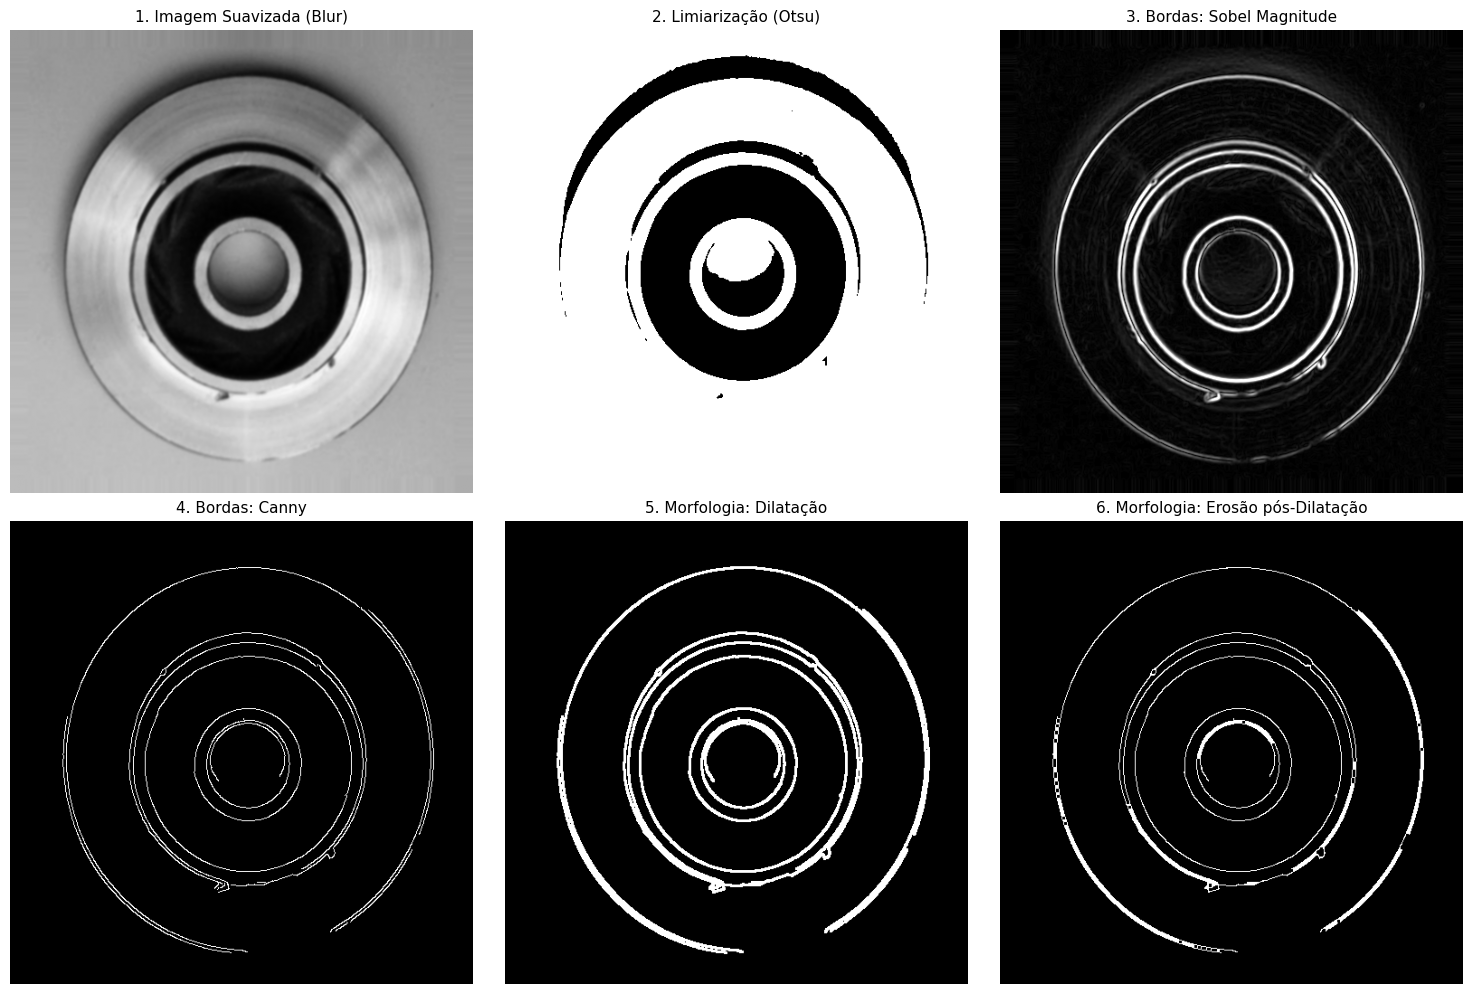

In [4]:
#Sprint 3 - Destaque de Características:

# Usamos o resultado do Gaussian Blur (kernel 5x5) da Célula 02 como base
# para garantir o isolamento correto das bordas sem ruído metálico
smooth_img = cv2.GaussianBlur(gray, (5, 5), 0)

# ==========================================
# 1. LIMIARIZAÇÃO (THRESHOLDING OTSU)
# ==========================================
# O método de Otsu calcula automaticamente o limiar ideal para separar
# o fundo da peça e destacar regiões de alto contraste (trincas/falhas)
_, thresh_otsu = cv2.threshold(smooth_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ==========================================
# 2. DETECÇÃO DE BORDAS (CANNY E SOBEL)
# ==========================================
# Canny: Algoritmo de múltiplos estágios para detectar gradientes intensos de bordas
edges_canny = cv2.Canny(smooth_img, threshold1=50, threshold2=150)

# Sobel: Calcula os gradientes horizontais (X) e verticais (Y)
sobelx = cv2.Sobel(smooth_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(smooth_img, cv2.CV_64F, 0, 1, ksize=3)
edges_sobel = cv2.magnitude(sobelx, sobely)
edges_sobel = np.uint8(np.clip(edges_sobel, 0, 255))

# ==========================================
# 3. OPERAÇÕES MORFOLÓGICAS (DILATAÇÃO E EROSÃO)
# ==========================================
# Elemento estruturante (kernel 3x3) para operar sobre as bordas do Canny
kernel = np.ones((3, 3), np.uint8)

# Dilatação: Expande as bordas detectadas para preencher falhas e fechar contornos desconectados
dilated = cv2.dilate(edges_canny, kernel, iterations=1)

# Erosão: Afina a estrutura dilatada para remover ruídos periféricos e manter apenas o núcleo do defeito
eroded = cv2.erode(dilated, kernel, iterations=1)

# ==========================================
# 4. EXIBIÇÃO E AUDITORIA VISUAL
# ==========================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(smooth_img, cmap='gray')
plt.title('1. Imagem Suavizada (Blur)', fontsize=11)
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(thresh_otsu, cmap='gray')
plt.title('2. Limiarização (Otsu)', fontsize=11)
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(edges_sobel, cmap='gray')
plt.title('3. Bordas: Sobel Magnitude', fontsize=11)
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(edges_canny, cmap='gray')
plt.title('4. Bordas: Canny', fontsize=11)
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(dilated, cmap='gray')
plt.title('5. Morfologia: Dilatação', fontsize=11)
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(eroded, cmap='gray')
plt.title('6. Morfologia: Erosão pós-Dilatação', fontsize=11)
plt.axis('off')

plt.tight_layout()
plt.show()

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.

✅ Classes identificadas automaticamente: ['def_front', 'ok_front']


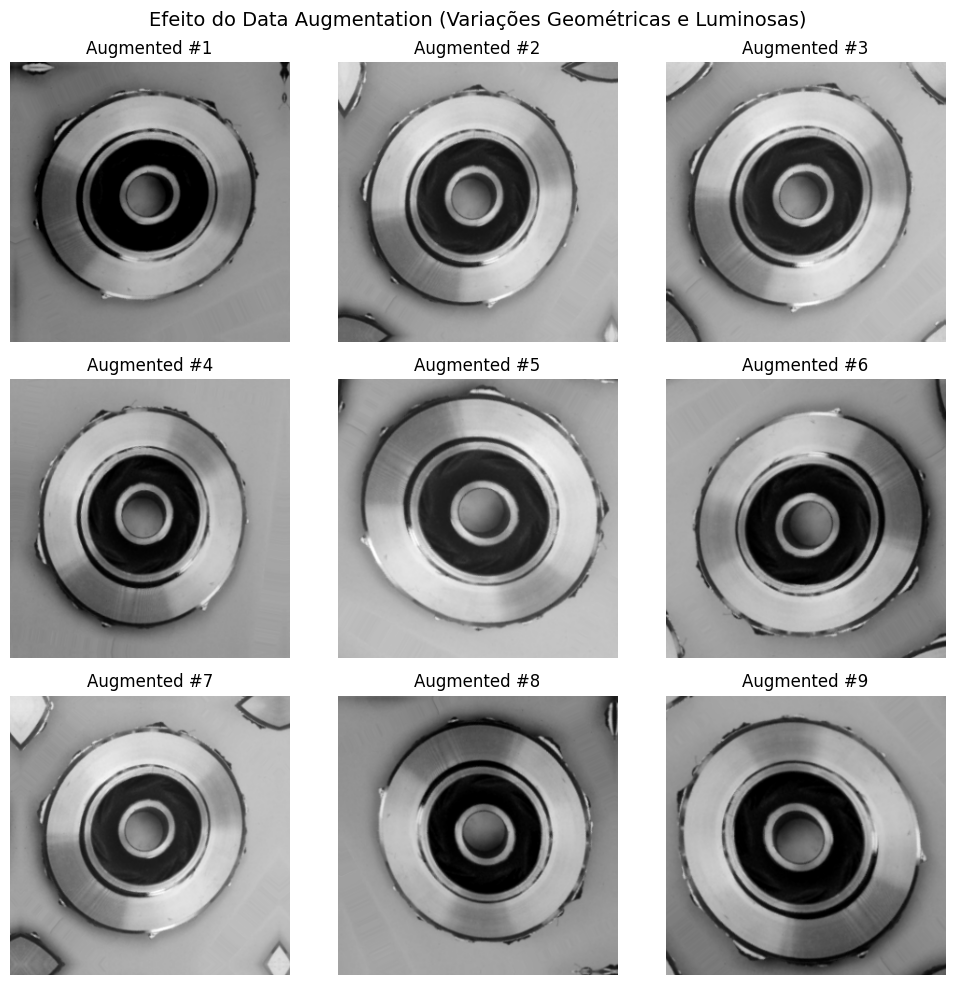

In [5]:
import tensorflow as tf
from tensorflow.keras import layers

#Sprint 4 - Ingestão de Dados e Augmentation (Keras)

# ==========================================
# 1. PARÂMETROS DE CARREGAMENTO
# ==========================================
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
SEED = 123

# ==========================================
# 2. INGESTÃO AUTOMATIZADA EM LOTE (80% TREINO / 20% VALIDAÇÃO)
# ==========================================
# Dataset de Treinamento
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'  # 0 = def_front, 1 = ok_front (ou vice-versa)
)

# Dataset de Validação
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Salvar os nomes das classes identificadas
class_names = train_ds.class_names
print(f"\n✅ Classes identificadas automaticamente: {class_names}")

# ==========================================
# 3. CONSTRUÇÃO DA CAMADA DE DATA AUGMENTATION
# ==========================================
# Simula variações na esteira industrial (giros, zoom, alterações de iluminação)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),      # Rotação aleatória de até 20%
    layers.RandomZoom(0.1),          # Zoom de até 10%
    layers.RandomBrightness(0.2)     # Variação de brilho de até 20%
], name="data_augmentation")

# ==========================================
# 4. OTIMIZAÇÃO DE PERFORMANCE DE LEITURA (AUTOTUNE)
# ==========================================
# Prefetch e Cache garantem alta velocidade na transferência para a GPU
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 5. VISUALIZAÇÃO DO DATA AUGMENTATION EM UMA AMOSTRA
# ==========================================
# Extrai 1 lote para demonstrar visualmente o efeito do Augmentation
for images, labels in train_ds.take(1):
    sample_image = images[0]

    plt.figure(figsize=(10, 10))
    for i in range(9):
        # Aplica as transformações dinâmicas sobre a mesma imagem
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0))

        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(augmented_image[0], tf.uint8))
        plt.title(f"Augmented #{i+1}")
        plt.axis("off")

    plt.suptitle("Efeito do Data Augmentation (Variações Geométricas e Luminosas)", fontsize=14)
    plt.tight_layout()
    plt.show()
    break

In [6]:
from tensorflow.keras import models, layers

#Sprint 5 - A Arquitetura CNN e Treinamento

# ==========================================
# 1. CONSTRUÇÃO DA ARQUITETURA CNN
# ==========================================
model = models.Sequential([
    # Camada de Entrada
    layers.Input(shape=(300, 300, 3)),

    # Aplicar o Data Augmentation definido na Sprint 4
    data_augmentation,

    # Normalização dos valores dos pixels de [0, 255] para [0, 1]
    layers.Rescaling(1./255),

    # Bloco Convolucional 1: Extração de recursos de baixo nível (bordas, curvas)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloco Convolucional 2: Extração de formas e texturas
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloco Convolucional 3: Extração de padrões complexos das falhas
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Transição e Classificação Binária
    layers.Flatten(),                                  # Achatamento da matriz em vetor 1D
    layers.Dense(64, activation='relu'),               # Camada totalmente conectada
    layers.Dropout(0.5),                               # Prevenção ativa de Overfitting
    layers.Dense(1, activation='sigmoid')              # Saída binária: 0 (def_front) ou 1 (ok_front)
], name="CNN_Casting_Inspection")

# ==========================================
# 2. COMPILAÇÃO DO MODELO
# ==========================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Exibe o resumo detalhado da arquitetura e quantidade de parâmetros
model.summary()

# ==========================================
# 3. TREINAMENTO DO MODELO
# ==========================================
EPOCHS = 15

print("\n🚀 Iniciando o treinamento da Rede Neural...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)
print("✅ Treinamento concluído com sucesso!")

Model: "CNN_Casting_Inspection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 298, 298, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 156800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    10,035,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,128,577 (38.64 MB)

 Trainable params: 10,128,577 (38.64 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Iniciando o treinamento da Rede Neural...
Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.5817 - loss: 0.8049 - val_accuracy: 0.6192 - val_loss: 0.6772
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.6038 - loss: 0.6742 - val_accuracy: 0.6192 - val_loss: 0.6005
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.6125 - loss: 0.6344 - val_accuracy: 0.7577 - val_loss: 0.6059
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.6337 - loss: 0.6214 - val_accuracy: 0.7346 - val_loss: 0.5351
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.6394 - loss: 0.6138 - val_accuracy: 0.6885 - val_loss: 0.5344
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.6923 - loss: 0.5992 - val_accuracy: 0.7346 - val_loss: 0.5286
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.7048 - loss: 0.5819 - val_accuracy: 0.7654 - val_loss: 0.4978
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0

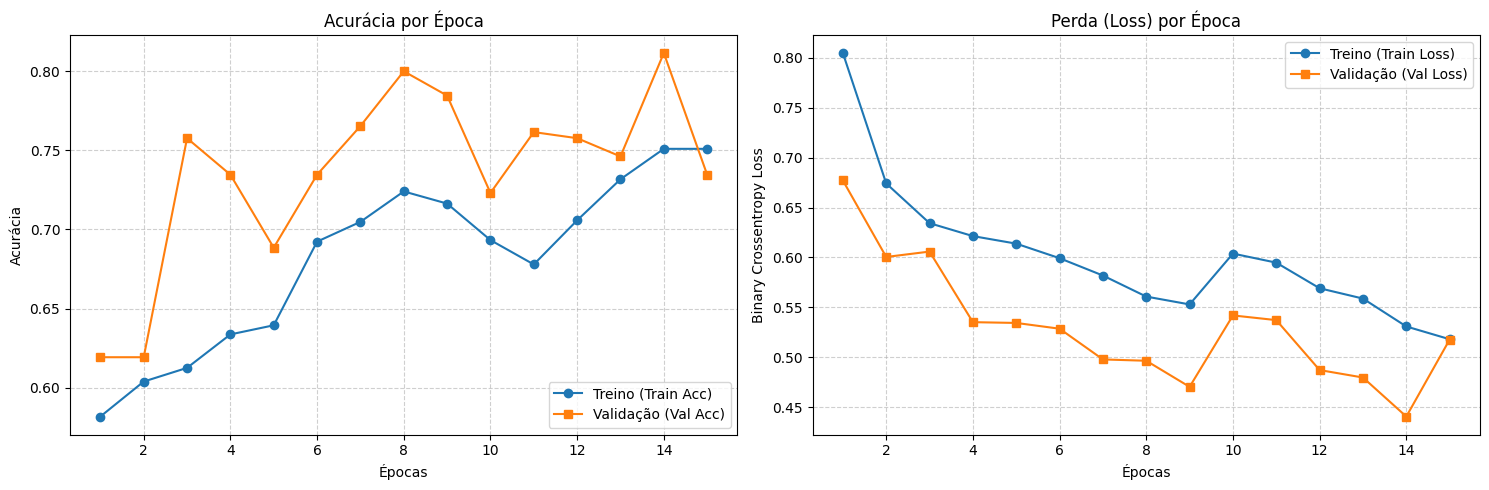

✅ Gráfico de auditoria salvo como 'training_history.png'


<Figure size 640x480 with 0 Axes>

In [8]:
#Sprint 6 - Auditoria e Gravação

# ==========================================
# 1. EXTRAÇÃO DO HISTÓRICO DE TREINAMENTO
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# ==========================================
# 2. PLOTAGEM DOS GRÁFICOS ANALÍTICOS
# ==========================================
plt.figure(figsize=(15, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Treino (Train Acc)')
plt.plot(epochs_range, val_acc, 's-', label='Validação (Val Acc)')
plt.title('Acurácia por Época', fontsize=12)
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Treino (Train Loss)')
plt.plot(epochs_range, val_loss, 's-', label='Validação (Val Loss)')
plt.title('Perda (Loss) por Época', fontsize=12)
plt.xlabel('Épocas')
plt.ylabel('Binary Crossentropy Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Salvar o gráfico para anexar no GitHub/README
plt.savefig('training_history.png', dpi=300)
print("✅ Gráfico de auditoria salvo como 'training_history.png'")

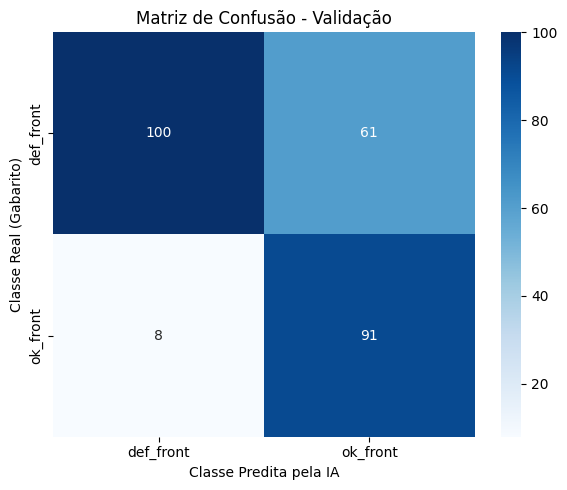


📋 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

   def_front       0.93      0.62      0.74       161
    ok_front       0.60      0.92      0.73        99

    accuracy                           0.73       260
   macro avg       0.76      0.77      0.73       260
weighted avg       0.80      0.73      0.74       260



In [9]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Obter os rótulos reais (y_true) e as predições do modelo (y_pred) no conjunto de validação
y_true = []
y_pred_probs = []

# Iterar sobre o dataset de validação para extrair imagens e rótulos
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Converter probabilidades (0.0 a 1.0) em classes binárias (0 ou 1) usando threshold de 0.5
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Gerar a Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

# 3. Plotar a Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Matriz de Confusão - Validação', fontsize=12)
plt.xlabel('Classe Predita pela IA')
plt.ylabel('Classe Real (Gabarito)')
plt.tight_layout()
plt.show()

# 4. Exibir o Relatório Detalhado (Precision, Recall, F1-Score)
print("\n📋 Relatório de Classificação Detalhado:")
print(classification_report(y_true, y_pred, target_names=class_names))